# Assignment 7: Visualization and Insight Communication

**Description**: Create a visual and summarize the **Top 3** insights from it to help with team decision-making.

-----------
## Scenario
Role-Play: the coach for an Eastern Conference Team would like some assistance in picking out the reserves for the 2026 Eastern Conference All-Star Team. This analysis will use scoring efficiency and other metrics as the foundational analysis to pick the 7 reserves.

## NBA All-Star Rules
**General Rules**
- There are 24 NBA All-Stars, 12 from each conference
- Players are chosen *without* regard to position
- Process for assigning players to the two U.S. Teams will be determined at a later date
- If NBA All-Star Voting doesn't result in the selection of 16 U.S. Players and 8 International Players (which can include U.S. players with ties to other countries, if necessary), then the NBA Commissioner Adam Silver will select additional All-Stars to join either group to reach that minimum. In this case, at least one team would have more than 8 players.

**Rules for NBA All-Star Starters**
- Fans Vote Daily for your Starters
- 5 Players per Conference
- Formula: Fans (50%), Current Players (25%), Media Panel (25%)

**Rules for NBA All-Star Reserves**
- Chosen by the NBA Head Coaches ***This is the Foundation of the Analysis***

### Notes for Analysis
- Data is Up-to-Date as of the End of Monday, January 12, 2026

-----------

The following six players currently lead the Eastern Conference in fan voting: 
- Tyrese Maxey,
- Jaylen Brown,
- Donovan Mitchell,
- Giannis Antetokounmpo,
- Jalen Brunson, and
- Cade Cunningham.

Given historical voting trends and All-Star selection patterns, it is highly likely that five of these players will be named Eastern Conference starters, with the remaining player positioned as a strong candidate for the first Eastern Conference reserve.

This analysis focuses on the remaining reserve spots for the Eastern Conference All-Star roster. By evaluating performance, availability, team success, and impact metrics, this review is intended to serve as a data-informed guide for the coaching staff when selecting the final 6 All-Star reserves.

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
from datetime import datetime
from collections import Counter

today = datetime.today() # Get Today's Date
formatted_date = today.strftime('%m%d%Y') # Strip Today's Date in the MMDDYYYY Format

In [2]:
# Define Estimated Advanced Metrics

# Shot Attempts
def shot_attempts(fga, fta):
    shot_attempts = fga + 0.44*fta
    return shot_attempts

#########################
# Usage
def usage (fga, fta, tov, tm_mp, mp, tm_fga, tm_fta, tm_tov, gp, tm_gp):
    # If any data is missing, then we return NAN
    if any(pd.isna(x) for x in [fga, fta, tov, tm_mp, mp, tm_fga, tm_fta, tm_tov]):
        return np.nan
    
    num = (fga + 0.44 * fta + tov) * (tm_mp/5)
    denom = (mp * (tm_fga + 0.44 * tm_fta + tm_tov))
    
    # Check for Divide-by-Zero
    if denom == 0:
        return np.nan

    # Calculate Usage
    usage = num / denom
    return usage
    
#########################
# Effective Field Goal Percentage (eFG%)
def eFG_percentage (fgm, made_3s, fga):
    num = (fgm + 0.5 * made_3s)
    denom = fga

    # Check for Divide-by-Zero
    if fga == 0:
        return np.nan
    
    # Calculate Effective Field Goal Percentage
    efg = num / denom
    return efg

#########################
# True Shooting Percentage (TS%)
def TS_percentage (pts, fga, fta):
    num = pts
    denom = 2 * (fga + 0.44 * fta)

    # Check for Divide-by-Zero
    if denom == 0:
        return np.nan

    # Calculate True Shooting Percentage
    ts = num / denom
    return ts

#########################
# Per 36-Minute Stat Calculator
def per36(stat_per_game, minutes_per_game):
    
    return stat_per_game * (36 / minutes_per_game)



#########################
# Gather Player Statistics
def get_player_data(df, player_name):
    player_df = df[df['Player'] == player_name]
    
    return player_df.reset_index(drop = True)

# Gather Team Statistics
def get_team_data(df, team_name):    
    team_df = df[df['Team'] == team_name]
    return team_df.reset_index(drop = True)

In [3]:
# Read Data
players = pd.read_excel("All-Star-Data.xlsx", sheet_name = "East Players 2025-26")
teams = pd.read_excel("All-Star-Data.xlsx", sheet_name = "East Teams Totals 2025-26")
opponents = pd.read_excel("All-Star-Data.xlsx", sheet_name = "East Teams Opp Totals 2025-26")

In [4]:
# Clean Data
# Get Averages for Teams and Opponents
columns_to_clean = ['MP',
       'FG', 'FGA', '3P', '3PA', '2P', '2PA', 'FT', 'FTA'
       , 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']

for field in columns_to_clean:
    teams[field] = teams[field] / teams["G"]
    opponents[field] = opponents[field] / opponents["G"]

In [5]:
# Add Prefixes to Columns to Help with Joins
players = players.rename(
    columns = lambda c: f"players_{c}"
)
teams = teams.rename(
    columns = lambda c: f"teams_{c}"
)
opponents = opponents.rename(
    columns = lambda c: f"opponents_{c}"
)

In [6]:
# Merge Tables Together
# First Players_Teams
players_teams = players.merge(
    teams,
    left_on = "players_Team",
    right_on = "teams_Team",
    how = "left"
)
# Second Players_Teams_Opponents
players_teams_opponents = players_teams.merge(
    opponents,
    left_on = "players_Team",
    right_on = "opponents_Team",
    how = "left"
)

In [7]:
# Calculate Advanced Metrics
# Shot Attempts
players_teams_opponents["players_Shot_Attempts"] = players_teams_opponents.apply(
    lambda row: shot_attempts(
        fga = row["players_FGA"],
        fta = row["players_FTA"]
    ),
    axis = 1
)

# Usage
players_teams_opponents["players_USG"] = players_teams_opponents.apply(
    lambda row: usage(
        fga = row["players_FGA"],
        fta = row["players_FTA"],
        tov = row["players_TOV"],
        tm_mp = row["teams_MP"],
        mp = row["players_MP"],
        tm_fga = row["teams_FGA"],
        tm_fta = row["teams_FTA"],
        tm_tov = row["teams_TOV"],
        gp = row["players_G"],
        tm_gp = row["teams_G"]
    ),
    axis = 1
)

players_teams_opponents["players_USG%"] = players_teams_opponents["players_USG"]*100

players_teams_opponents["players_TS%"] = 100*players_teams_opponents.apply(
    lambda row: TS_percentage(
        pts = row["players_PTS"],
        fga = row["players_FGA"],
        fta = row["players_FTA"]
    ),
    axis = 1
)



In [8]:
players_teams_opponents

,players_Player,players_Second Fan Returns,players_Team,players_Wins,players_Losses,players_Conference Seeding,players_Country,players_Pos,players_G,players_GS,...,opponents_AST,opponents_STL,opponents_BLK,opponents_TOV,opponents_PF,opponents_PTS,players_Shot_Attempts,players_USG,players_USG%,players_TS%
0,Tyrese Maxey,1908978,Philadelphia 76ers,21,16,5,NaN,PG,35,35,...,26.972973,7.513514,5.243243,15.162162,20.918919,115.513514,25.460,0.295919,29.591929,60.683425
1,Jaylen Brown,1514259,Boston Celtics,24,14,3,NaN,SF,36,36,...,25.526316,5.552632,4.236842,13.736842,18.736842,110.447368,25.068,0.362762,36.276241,58.839955
2,Donovan Mitchell,1530237,Cleveland Cavaliers,22,18,7,NaN,SG,36,36,...,27.275000,8.650000,4.400000,16.000000,20.600000,117.575000,23.684,0.327853,32.785310,62.911670
3,Giannis Antetokounmpo,2092284,Milwaukee Bucks,17,22,11,NaN,PF,25,25,...,26.666667,8.282051,4.051282,14.000000,18.897436,115.076923,21.424,0.372331,37.233078,68.147872
4,Jalen Brunson,1916497,New York Knicks,25,14,2,NaN,PG,36,36,...,25.358974,7.230769,4.615385,13.897436,19.692308,114.923077,24.128,0.313663,31.366267,59.888926
5,Cade Cunningham,1752801,Detroit Pistons,28,10,1,NaN,PG,33,33,...,23.236842,9.394737,5.710526,17.315789,22.394737,111.236842,23.112,0.311972,31.197230,57.762201
6,Michael Porter Jr.,304316,Brooklyn Nets,11,25,13,NaN,SF,29,29,...,27.416667,8.638889,4.694444,14.472222,20.583333,113.861111,20.724,0.302268,30.226786,62.487937
7,Norman Powell,1,Miami Heat,20,19,8,USA,SG,33,33,...,27.282051,8.512821,5.461538,16.153846,20.282051,117.717949,18.908,0.275911,27.591058,62.936323
8,Joel Embiid,1,Philadelphia 76ers,21,16,5,NaN,C,19,19,...,26.972973,7.513514,5.243243,15.162162,20.918919,115.513514,20.532,0.334538,33.453782,57.227742
9,Jalen Johnson,525789,Atlanta Hawks,20,21,9,NaN,SF,37,37,...,27.682927,9.073171,4.731707,16.024390,18.756098,118.365854,19.220,0.268558,26.855819,61.654527


In [9]:
# Filter Out the Dataset for Eligible Players

# Players that are 11th Seed or Higher
players_teams_opponents = players_teams_opponents[
    players_teams_opponents["players_Conference Seeding"] < 11
]

# Players that Played at Least 30 Games
players_teams_opponents = players_teams_opponents[
    players_teams_opponents["players_G"] >= 30
]

# Players that Have at Least 20% Usage Rates
players_teams_opponents = players_teams_opponents[
    players_teams_opponents["players_USG"] >= 0.2
]

# Players that Have at Least 56% TS%
players_teams_opponents = players_teams_opponents[
    players_teams_opponents["players_TS%"] >= 54
]

# Players that Have Less Than 1M Fan Votes
# Data Has at Least 1 Vote for Every Player
# Filter Out Probable Starters
players_teams_opponents = players_teams_opponents[
    players_teams_opponents["players_Second Fan Returns"] <= 1000000
]

In [10]:
# Clean Up Table
players_teams_opponents = (
    players_teams_opponents
        .sort_values(by="players_Conference Seeding", ascending=True)
        .reset_index(drop=True)
)

In [11]:
# Clean Up Table
players_teams_opponents = (
    players_teams_opponents
        .sort_values(by="players_TS%", ascending=False)
        .reset_index(drop=True)
)

In [12]:
players_teams_opponents

,players_Player,players_Second Fan Returns,players_Team,players_Wins,players_Losses,players_Conference Seeding,players_Country,players_Pos,players_G,players_GS,...,opponents_AST,opponents_STL,opponents_BLK,opponents_TOV,opponents_PF,opponents_PTS,players_Shot_Attempts,players_USG,players_USG%,players_TS%
0,Jalen Duren,1,Detroit Pistons,28,10,1,NaN,C,31,31,...,23.236842,9.394737,5.710526,17.315789,22.394737,111.236842,13.420,0.226746,22.674550,66.691505
1,Norman Powell,1,Miami Heat,20,19,8,USA,SG,33,33,...,27.282051,8.512821,5.461538,16.153846,20.282051,117.717949,18.908,0.275911,27.591058,62.936323
2,Jalen Johnson,525789,Atlanta Hawks,20,21,9,NaN,SF,37,37,...,27.682927,9.073171,4.731707,16.024390,18.756098,118.365854,19.220,0.268558,26.855819,61.654527
3,Karl-Anthony Towns,898038,New York Knicks,25,14,2,NaN,C,36,36,...,25.358974,7.230769,4.615385,13.897436,19.692308,114.923077,17.492,0.260612,26.061169,60.599131
4,Scottie Barnes,1,Toronto Raptors,24,16,4,USA,PF,39,39,...,24.400000,8.200000,5.600000,15.900000,19.750000,112.275000,16.572,0.237884,23.788391,58.532464
5,Nikola Vucevic,1,Chicago Bulls,18,20,10,NaN,C,37,37,...,27.631579,8.868421,5.763158,12.605263,19.052632,120.842105,14.116,0.214319,21.431884,58.444319
6,Nickeil Alexander-Walker,1,Atlanta Hawks,20,21,9,Canada,SG,39,32,...,27.682927,9.073171,4.731707,16.024390,18.756098,118.365854,17.716,0.252031,25.203069,58.139535
7,Evan Mobley,1,Cleveland Cavaliers,22,18,7,NaN,PF,34,32,...,27.275000,8.650000,4.400000,16.000000,20.600000,117.575000,15.512,0.221391,22.139110,58.019598
8,Josh Giddey,1,Chicago Bulls,18,20,10,NaN,PG,30,30,...,27.631579,8.868421,5.763158,12.605263,19.052632,120.842105,16.632,0.258199,25.819948,57.720058
9,CJ McCollum,1,Atlanta Hawks,20,21,9,NaN,PG,36,35,...,27.682927,9.073171,4.731707,16.024390,18.756098,118.365854,16.376,0.245012,24.501237,56.790425


In [13]:
players_teams_opponents.to_excel("players_teams_opponents.xlsx", index = False)

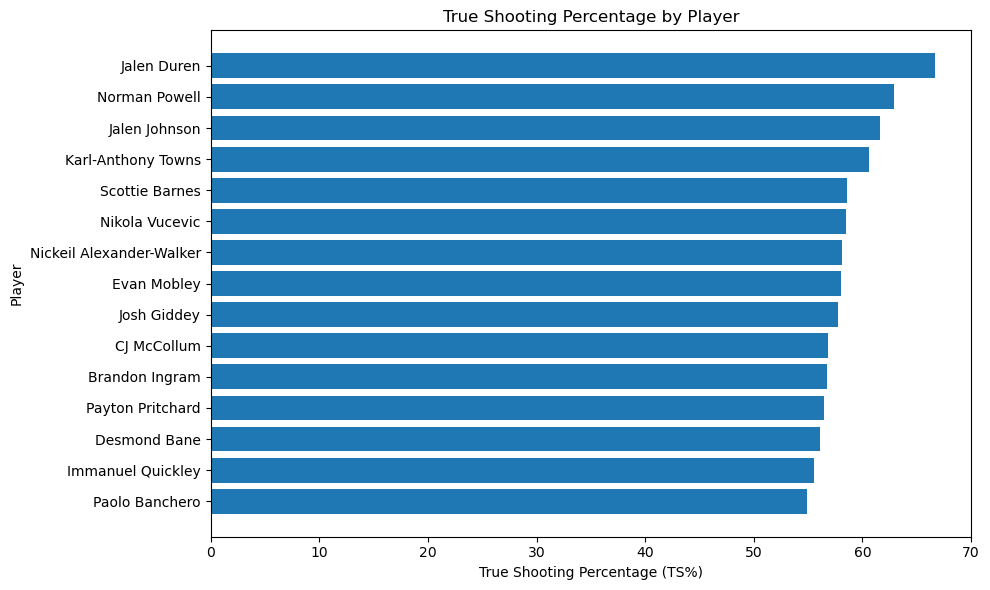

In [14]:
import matplotlib.pyplot as plt

# Sort by TS% so the chart is easier to read
df_sorted = players_teams_opponents.sort_values(
    by="players_TS%", ascending=True
)

# Create the plot
plt.figure(figsize=(10, 6))
plt.barh(
    df_sorted["players_Player"],
    df_sorted["players_TS%"]
)

# Labels & title
plt.xlabel("True Shooting Percentage (TS%)")
plt.ylabel("Player")
plt.title("True Shooting Percentage by Player")


plt.tight_layout()
plt.show()


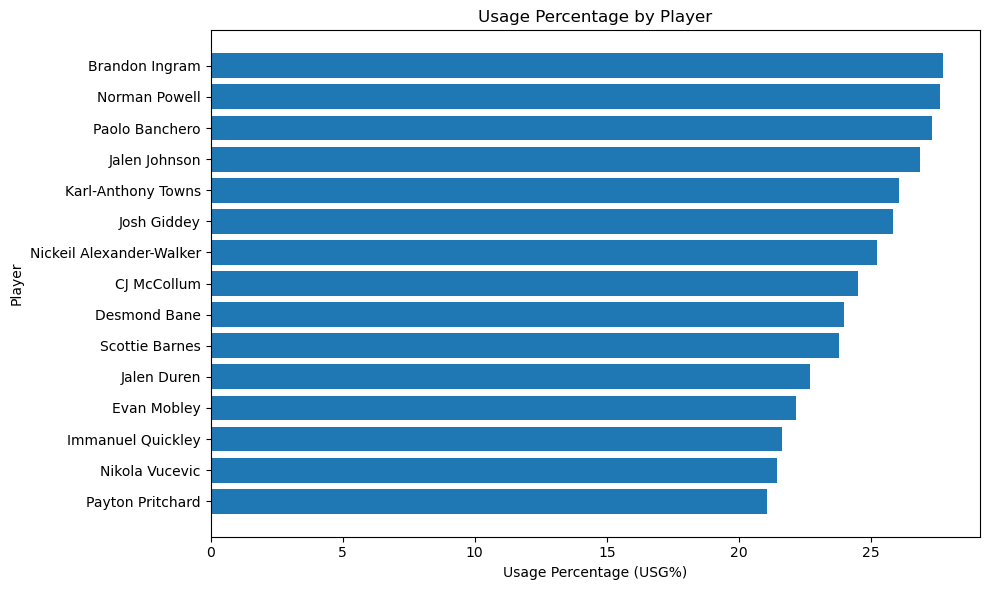

In [15]:
import matplotlib.pyplot as plt

# Sort by USG% so the chart is easier to read
df_sorted = players_teams_opponents.sort_values(
    by="players_USG%", ascending=True
)

# Create the plot
plt.figure(figsize=(10, 6))
plt.barh(
    df_sorted["players_Player"],
    df_sorted["players_USG%"]
)

# Labels & title
plt.xlabel("Usage Percentage (USG%)")
plt.ylabel("Player")
plt.title("Usage Percentage by Player")


plt.tight_layout()
plt.show()


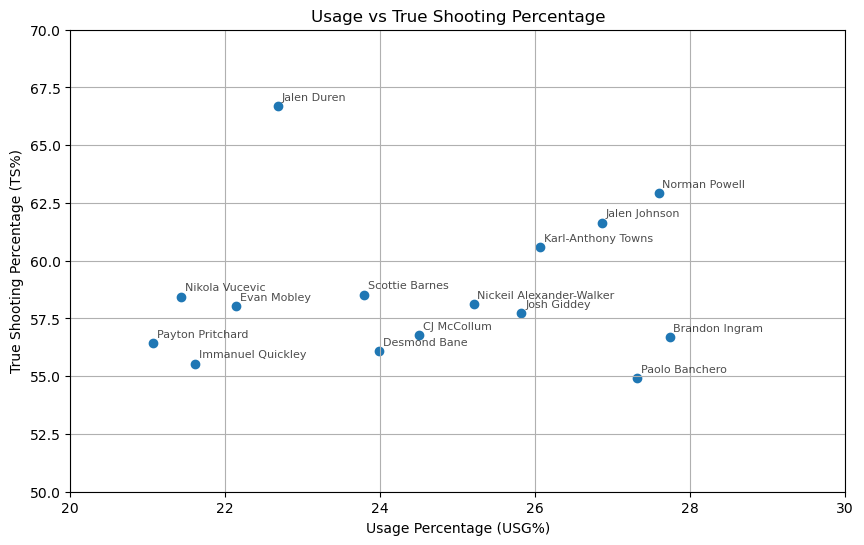

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    players_teams_opponents["players_USG%"].astype(float),
    players_teams_opponents["players_TS%"].astype(float)
)

x_offset = 0.05   # move right
y_offset = 0.25   # move up

# Label each point with player name
for _, row in players_teams_opponents.iterrows():
    plt.text(
        row["players_USG%"] + x_offset,
        row["players_TS%"] + y_offset,
        row["players_Player"],
        fontsize=8,
        alpha=0.7
    )

plt.xlabel("Usage Percentage (USG%)")
plt.ylabel("True Shooting Percentage (TS%)")
plt.title("Usage vs True Shooting Percentage")
plt.grid(True)

plt.xlim(20, 30)   # Typical USG% range
plt.ylim(50, 70)   # Typical TS% range


plt.show()
